In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 10 — Stability, diagram distances, noise, and scientific uncertainty

Read `lessons/10_lesson.md` first. Predict each result before execution. This is a fully worked lab; independent exercises and solutions are separate. All real examples before Stage 12 restrict digit displays to training data.

## Setup
This cell locates the project, loads standard numerical tools, and creates only this stage’s output folder. The mathematical work begins below.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "data/manifest.json").exists() and (p / "src/shape_lab").exists()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the extracted listening_to_shape_lab folder.")
sys.path.insert(0, str(ROOT / "src"))
from shape_lab.display import show_and_save, save_json
OUT = ROOT / "reports/stage_10"
OUT.mkdir(parents=True, exist_ok=True)
print("Output folder:", OUT.relative_to(ROOT))

Output folder: reports/stage_10


## Exact bottleneck examples
Matching a bar to the diagonal costs half its lifetime in the maximum norm.

In [3]:
from shape_lab.persistence import finite_bottleneck, pixel_filtration, persistent_homology, diagram
assert finite_bottleneck([[0,2]],[]) == 1
assert np.isclose(finite_bottleneck([[0,2]],[[.1,2.1]]),.1)
print("One bar versus empty:",finite_bottleneck([[0,2]],[]))

One bar versus empty: 1.0


## Real data: bounded perturbations on a fixed pixel grid
We compare finite H₁ diagrams. The completed rectangular domain has no essential H₁, so no H₁ classes are silently discarded.

 sample_id  requested_amplitude  actual_sup_change  H1_bottleneck  bound_passed
         0                 0.01           0.009868       0.000878          True
         0                 0.03           0.028805       0.008583          True
         0                 0.07           0.069488       0.044060          True
         0                 0.12           0.115088       0.063029          True
         1                 0.01           0.009909       0.002377          True
         1                 0.03           0.029653       0.003060          True
         1                 0.07           0.069959       0.007181          True
         1                 0.12           0.119118       0.032935          True
         2                 0.01           0.009923       0.009770          True
         2                 0.03           0.029746       0.027747          True
         2                 0.07           0.068566       0.024860          True
         2                 0.12         

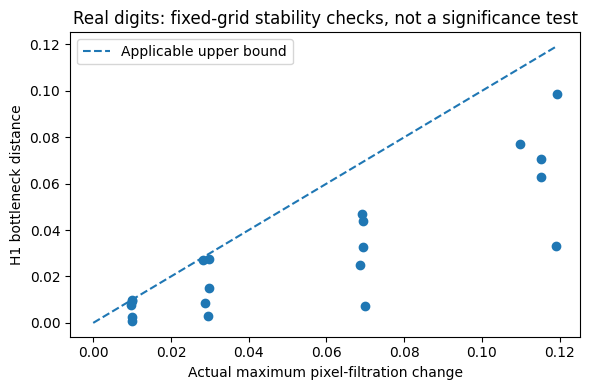

In [4]:
from shape_lab.data import load_digit_data
images,labels,ids=load_digit_data("train")
rows=[]
for i in range(5):
    base=1-images[i].astype(float)/16
    before=diagram(persistent_homology(pixel_filtration(base)),1)
    assert np.isfinite(before).all()
    for amplitude in [.01,.03,.07,.12]:
        rng=np.random.default_rng(500+i*10+int(amplitude*100))
        after=np.clip(base+rng.uniform(-amplitude,amplitude,base.shape),0,1)
        delta=float(np.max(abs(base-after)))
        dgm_after=diagram(persistent_homology(pixel_filtration(after)),1)
        distance=finite_bottleneck(before,dgm_after)
        assert distance <= delta + 1e-10
        rows.append({"sample_id":int(ids[i]),"requested_amplitude":amplitude,
                     "actual_sup_change":delta,"H1_bottleneck":distance,"bound_passed":True})
print(pd.DataFrame(rows).to_string(index=False))
plt.figure(figsize=(6,4))
plt.scatter([r["actual_sup_change"] for r in rows],[r["H1_bottleneck"] for r in rows])
lim=max(r["actual_sup_change"] for r in rows)
plt.plot([0,lim],[0,lim],linestyle="--",label="Applicable upper bound")
plt.xlabel("Actual maximum pixel-filtration change"); plt.ylabel("H1 bottleneck distance")
plt.legend(); plt.title("Real digits: fixed-grid stability checks, not a significance test")
show_and_save(OUT / "stability_checks.png")
save_json(OUT / "results.json", {"checks":rows,"check_count":len(rows),
          "claim":"Bounded fixed-grid H1 sensitivity only; no unseen-writer or significance claim."})

## Explain the result
Why do we record actual perturbation after clipping? Why is a passed bound not a p-value? Answer both before proceeding.

## Mastery gate
Apply a precise stability statement, compute a diagram distance, and separate robustness from statistical significance.

A successful Run All is computational evidence, not a learner pass. Complete the lesson’s original exercises before reading `solutions/10_solutions.md`. Record independent work, corrections and a delayed re-test in your learner ledger.

## Sources and conventions
Source IDs: R2, R8, L3, R9; direct links and assignments are in `docs/SOURCES.md`. Core conventions are in `docs/MATHEMATICAL_CONVENTIONS.md`.